In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
base_dir = '../../'
cell_table_path=base_dir+'segmentation/cell_table_Denoised/cell_table_size_normalized.csv'
biosamples_path=base_dir+'IMC_data/ExtraDocs/processed_response.csv'
intensities = pd.read_csv(cell_table_path)
if 'cell_meta_cluster' in intensities.columns:
    intensities = intensities[intensities['cell_meta_cluster']!='Unassigned']#remove cells that have not been assigned yet
biosamples =pd.read_csv(biosamples_path)
intensities_protein = intensities.iloc[:,1:intensities.columns.get_loc('label')]#proteins are from the second columns up to the column called label
adata = sc.AnnData(intensities_protein, obsm={"spatial": intensities[['centroid-0', 'centroid-1']].values})


/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Show those genes that yield the highest fraction of counts in each single cell, across all cells

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Categorica

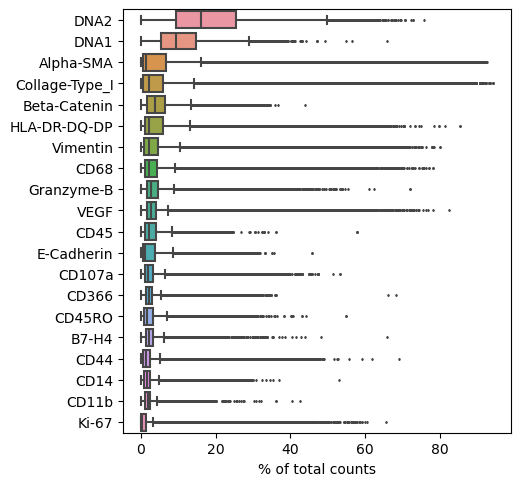

In [3]:
sc.pl.highest_expr_genes(adata, n_top=20, )


In [4]:
adata.raw = adata

In [24]:
#pd.DataFrame(np.quantile(adata.raw.X,0.95,axis = 0),adata.var.index)

normalise every channel independently to the 95 percentile

In [5]:
q = np.quantile(adata.X,q = 0.95,axis = 0)
adata.X = adata.X/q
adata.X[adata.X>1] = 1

If cells have low dna, it is likely that cells are rubbish, so we filter them out

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


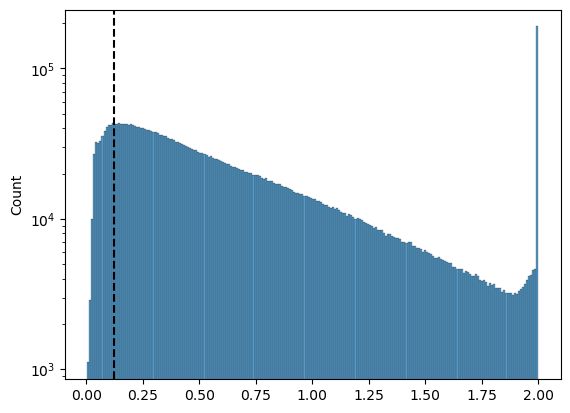

In [219]:
dna_count = adata[:,adata.var.index.isin(['DNA1', 'DNA2'])].X.sum(axis = 1)
sns.histplot(dna_count)
plt.semilogy()
dna_thr = np.quantile(dna_count,0.1)
plt.axvline(dna_thr,ls = '--',c = 'k')

In [ ]:
adata=adata[dna_count>dna_thr]

For phenotyping , we  want the cells to express some markers, but not all together at the same time.
We are gonna use lower and higher bounds of total expression. Also remove DNA and Carboplatin as they do not have a role in phenotyping

In [ ]:
adata.raw

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


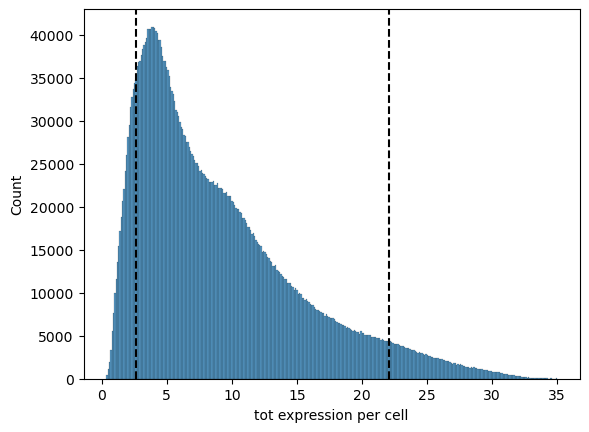

In [220]:
tot_counts = adata[:,~adata.var.index.isin(['DNA1', 'DNA2','Carboplatin'])].X.sum(axis = 1)
sns.histplot(tot_counts)
plt.xlabel('tot expression per cell')
plt.axvline(np.quantile(tot_counts,0.10),c = 'k',ls = '--')
plt.axvline(np.quantile(tot_counts,0.95),c = 'k',ls = '--')

In [ ]:
adata = adata[(tot_counts>np.quantile(tot_counts,0.10))*(tot_counts<np.quantile(tot_counts,0.95))]

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


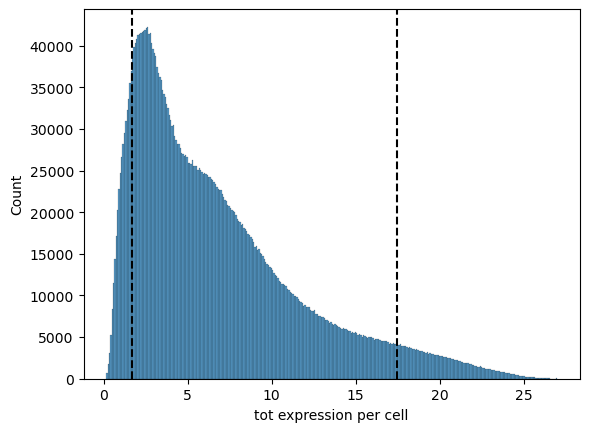

In [7]:
channels = ['CD38', 'CD14', 'Tbet', 'CD16', 'CD163',
       'Pan-keratin', 'CD11b', 'CD107a', 'CD45', 'CD44', 'CD366',
       'FOXP3', 'CD4', 'E-Cadherin', 'CD68', 'HLA-DR-DQ-DP', 'CD20',
       'CD8a', 'Beta-Catenin', 'B7-H4', 'Granzyme-B',
       'CD3', 'CD27', 'CD45RO',
       'Alpha-SMA', 'Vimentin', 'CD31' ]
tot_counts = adata[:,adata.var.index.isin(channels)].X.sum(axis = 1)
sns.histplot(tot_counts)
plt.xlabel('tot expression per cell')
plt.axvline(np.quantile(tot_counts,0.10),c = 'k',ls = '--')
plt.axvline(np.quantile(tot_counts,0.95),c = 'k',ls = '--')

In [ ]:
len(channels)

In [ ]:
adata=adata[adata.obs.total_counts>]


In [ ]:
adata.obs

In [ ]:
low_dna = adata[dna_count<0.1]
tot_counts = low_dna[:,~low_dna.var.index.isin(['DNA1', 'DNA2','Carboplatin'])].X.sum(axis = 1)
sns.histplot(tot_counts)
plt.xlabel('tot expression per cell')
plt.axvline(np.quantile(tot_counts,0.10),c = 'k',ls = '--')
plt.axvline(np.quantile(tot_counts,0.95),c = 'k',ls = '--')

In [ ]:
plt.hist(adata.X.reshape(-1),cumulative=True)

In [ ]:
plt.hist(adata.X.reshape(-1),bins = 30)

In [9]:
def discretise(adata,thr):
    '''binarise the counts to 0/1'''
    return adata.X>thr


In [32]:
dna_count = adata[:,adata.var.index.isin(['DNA1', 'DNA2'])].X.sum(axis = 1)
tot_counts = adata[:,adata.var.index.isin(channels)].X.sum(axis = 1)
tot_genes = discretise(adata[:,adata.var.index.isin(channels)],thr = 0.5).sum(axis = 1)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Percent'>

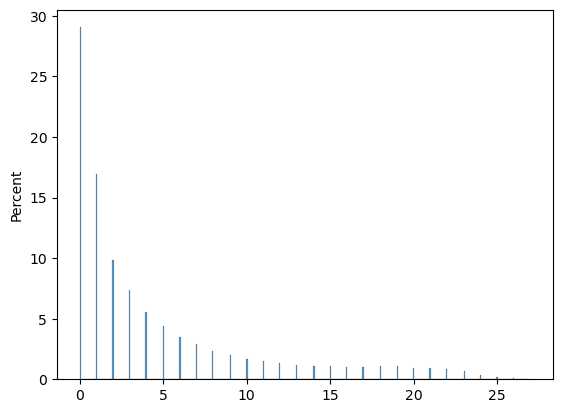

In [33]:
sns.histplot(tot_genes,stat = 'percent')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Percent'>

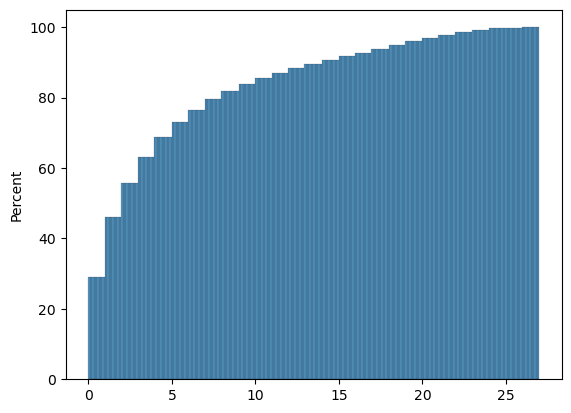

In [34]:
sns.histplot(tot_genes,stat = 'percent',cumulative=True)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 

<Axes: ylabel='Count'>

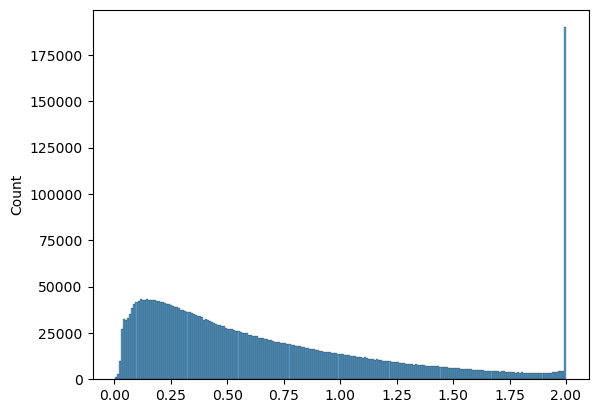

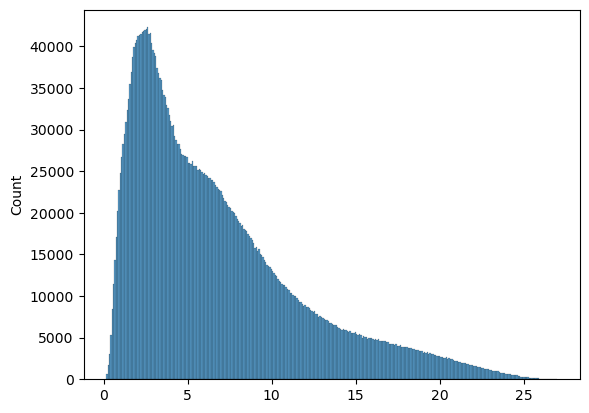

In [12]:
sns.histplot(dna_count)
plt.figure()
sns.histplot(tot_counts)

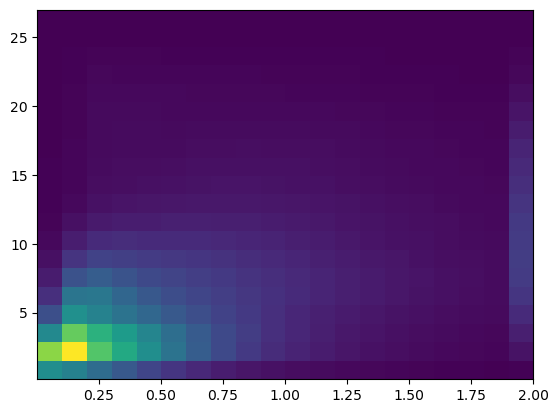

In [230]:
_ = plt.hist2d(dna_count,tot_counts,bins = 20)


<Figure size 640x480 with 0 Axes>

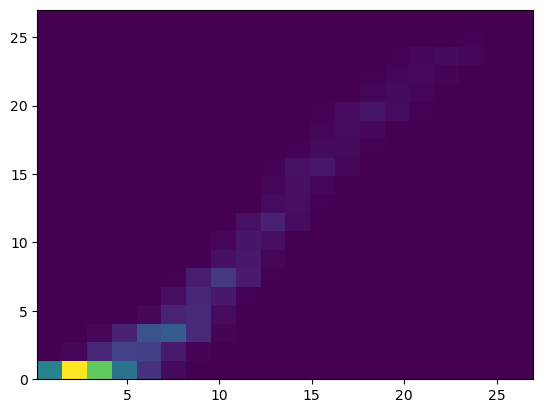

<Figure size 640x480 with 0 Axes>

In [19]:
_ = plt.hist2d(tot_counts, tot_genes,bins = 20)
plt.figure()


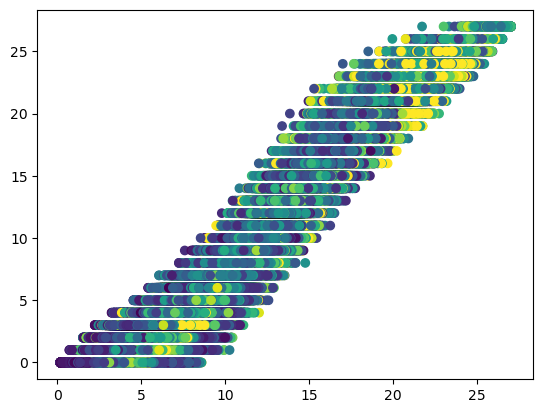

In [20]:
plt.scatter(tot_counts, tot_genes,c = dna_count)

In [194]:
tot_counts = discretise(adata[:,adata.var.index.isin(channels)],thr = 0.5).sum(axis = 1)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Percent'>

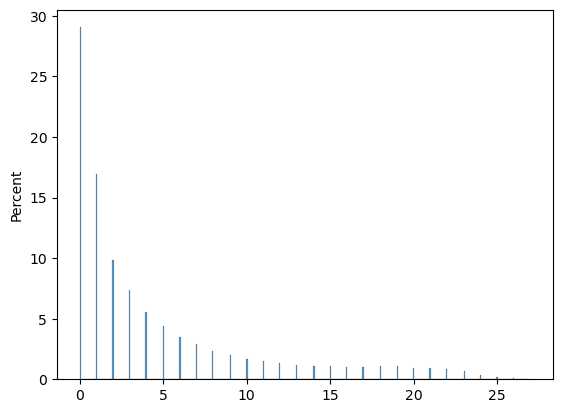

In [195]:
sns.histplot(tot_counts,stat='percent')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


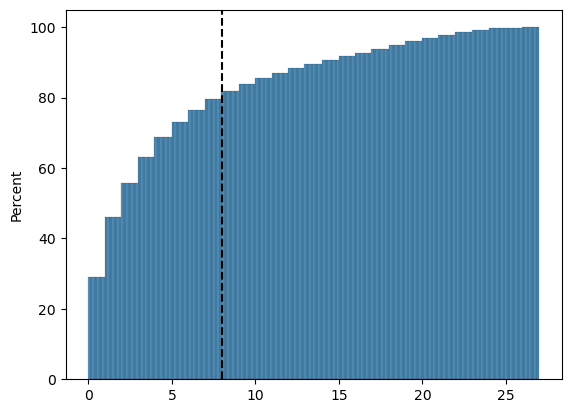

In [201]:
sns.histplot(tot_counts,stat='percent',cumulative=True)
plt.axvline(np.quantile(tot_counts,.80),ls = '--',c ='k')
#plt.axhline(10,ls = '--',c ='k')

In [193]:
np.quantile(tot_counts,0.8)

15.0

In [ ]:
from collections import Counter

In [ ]:
b,c = list(zip(*Counter(tot_counts).items()))

In [ ]:
Counter(a)

In [ ]:
plt.bar(b,np.array(c)/sum(c),0.5)

In [ ]:
plt.bar(np.arange(len(b)),np.cumsum(c)/sum(c),0.5)

(array([  5311.,  49495.,  71402.,  79832.,  91070.,  94535.,  94866.,
         94732.,  94397.,  93466.,  92016.,  90034.,  88310.,  85861.,
         83859.,  81952.,  79513.,  77590.,  75423.,  72346.,  71092.,
         68547.,  66036.,  64197.,  62016.,  60256.,  58649.,  57090.,
         55042.,  53875.,  52017.,  50754.,  49197.,  47998.,  46585.,
         44909.,  44336.,  43141.,  42023.,  40424.,  39438.,  38669.,
         37546.,  36375.,  35133.,  34242.,  32877.,  32283.,  31234.,
         30586.,  29557.,  28781.,  27596.,  26824.,  26320.,  25784.,
         24511.,  23581.,  23359.,  22480.,  21802.,  20912.,  20131.,
         19701.,  18726.,  18429.,  17378.,  17326.,  16466.,  15994.,
         15351.,  15400.,  14441.,  14099.,  13559.,  13301.,  12730.,
         12209.,  11929.,  11653.,  11235.,  10629.,  10238.,   9935.,
          9722.,   9229.,   9325.,   8728.,   8248.,   8224.,   7841.,
          7637.,   7321.,   7119.,   7067.,   7167.,   7907.,   8526.,
      

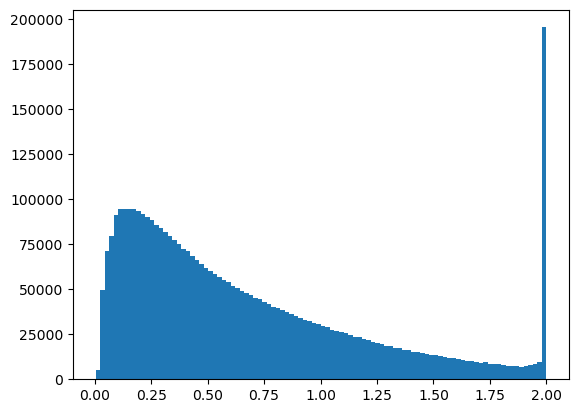

In [213]:
plt.hist(adata[:,adata.var.index.isin(['DNA1','DNA2'])].X.sum(axis = 1),bins = 100)

In [ ]:
list(zip(c,np.cumsum(c)))